# Setup the environment
Run the following two blocks to set up the environment.

In [205]:
# !git clone https://github.com/HaizhouZ/lab4_student
# %cd lab4_student

After running the following install command, **restart the notebook session**. Then start the lab4 main part

In [206]:
# !pip install -e ".[dev]"

# Lab 4

In [207]:
# %cd ..
# run this block if you are not in the lab4 folder

In [208]:
import numpy as np
import os
os.environ['MUJOCO_GL'] = 'egl'
import mujoco
import matplotlib.pyplot as plt
import math
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from pathlib import Path

from lab4.catch_controller import (
    CatchConfig,
    CatchController,
    TargetSource,
    TaskSpaceGains,
    run_catch_loop,
)

def find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / 'rsc' / 'planar3' / 'scene.xml').exists() and (parent / 'src').exists():
            return parent
    raise FileNotFoundError('Could not find repo root from current working directory')


repo_root = find_repo_root(Path.cwd())
scene_path = repo_root / 'rsc' / 'planar3' / 'scene.xml'

mj_model = mujoco.MjModel.from_xml_path(str(scene_path))

renderer = mujoco.Renderer(mj_model, width=640, height=480)
frames = []

def capture_step(model: mujoco.MjModel, data: mujoco.MjData, step_index: int) -> None:
    if step_index % RENDER_STRIDE == 0:
        renderer.update_scene(data)
        frames.append(renderer.render().copy())

## Understanding the Kinematics

### Coordinates

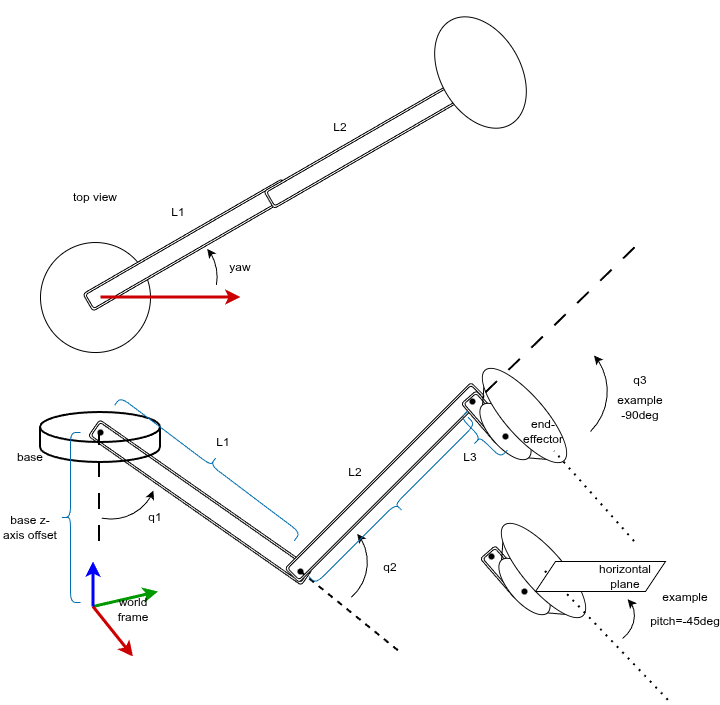

the zero joint angle configuration corresponds to:
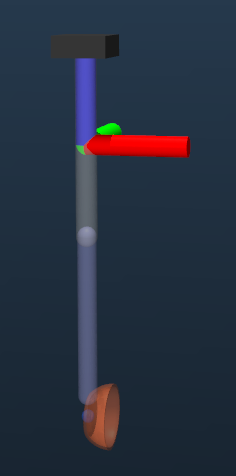


 the forward kinematics model follows these steps:

 1. **Coordinate Transformation (Link Angles)**: The code maps $q_1 = 0$ to a vertical "down" position. The subsequent angles $t_i$ represent the absolute pitch of each link relative to the horizontal plane:$$t_1 = q_1 - \frac{\pi}{2}$$$$t_2 = t_1 + q_2$$$$t_3 = t_2 + q_3$$
 2. **Radial Reach and Height**: The total radial distance $r$ (projection on the XY plane) and the height $z$ are calculated using the sum of the link projections:$$r = \sum_{i=1}^{3} l_i \cos(t_i)$$$$z = z_{\text{base}} + \sum_{i=1}^{3} l_i \sin(t_i)$$
 3. **3D Mapping**: Finally, the reach is decomposed into $x$ and $y$ using the $yaw$ angle, and the end-effector pitch $\phi$ is assigned the absolute angle of the final link:$$x = r \cos(\text{yaw})$$$$y = r \sin(\text{yaw})$$$$\phi = t_3$$

 **HINT**:

 1. compute the partial derivatives of $r$ wrt [yaw, q1, q2, q3]
 2. use the chain rule to compute the derivatives of [x,y,z,phi] wrt to [yaw, q1, q2, q3]
 $$
 \frac{\partial [x,y,z,phi]}{\partial [yaw, q1, q2, q3]}=\frac{\partial [x,y,z,phi]}{\partial r} \frac{\partial r}{\partial [yaw, q1, q2, q3]}
 $$

## Student Implementation

In [209]:
class StudentCatchController(CatchController):
  def __init__(self, q_home: np.ndarray, gains: TaskSpaceGains, catch_cfg: CatchConfig) -> None:
      super().__init__(q_home, gains, catch_cfg)

  def task_jacobian(self, q: np.ndarray) -> np.ndarray:
    """
    student todo: Computes the 4x4 analytic Jacobian for the planar robot.
    Rows order: [dx, dy, dz, dphi]
    Cols order: [dq_yaw, dq1, dq2, dq3]
    e.g. jac[0][0] = dx/dq_yaw, jac[1][1] = dy/dq1
    """
    yaw, q1, q2, q3 = q
    l1, l2, l3 = self.link_lengths
    ########## implement your jacobian
    jac = np.zeros((4, 4))

    t1 = q1 - math.pi/2
    t2 = t1 + q2
    t3 = t2 + q3
    phi = t3
    r = l1*math.cos(t1)+l2*math.cos(t2)+l3*math.cos(t3)
    x = r*math.cos(yaw)
    y = r*math.sin(yaw)
    z_base = 0
    z = z_base + l1*math.sin(t1) + l2*math.sin(t2) + l3*math.sin(t3)


    dr_dq1 = -l1*math.sin(t1) - l2*math.sin(t2) - l3*math.sin(t3)
    dr_dq2 = -l2*math.sin(t2) - l3*math.sin(t3)
    dr_dq3 = -l3*math.sin(t3)


    jac[0, 0] = -r * math.sin(yaw)
    jac[0, 1] = dr_dq1 * math.cos(yaw)
    jac[0, 2] = dr_dq2 * math.cos(yaw)
    jac[0, 3] = dr_dq3 * math.cos(yaw)

    jac[1, 0] = r * math.cos(yaw)
    jac[1, 1] = dr_dq1 * math.sin(yaw)
    jac[1, 2] = dr_dq2 * math.sin(yaw)
    jac[1, 3] = dr_dq3 * math.sin(yaw)

    jac[2, 0] = 0
    jac[2, 1] = l1*math.cos(t1) + l2*math.cos(t2) + l3*math.cos(t3)
    jac[2, 2] = l2*math.cos(t2) + l3*math.cos(t3)
    jac[2, 3] = l3*math.cos(t3)

    jac[3, 0] = 0
    jac[3, 1] = 1
    jac[3, 2] = 1
    jac[3, 3] = 1

    return jac
    # except raise NotImplementedError("Student should implement the task space jacobian")
  def _compute_task_space_tau(
        self,
        jacobian: np.ndarray,
        pos_err: np.ndarray,
        vel_err: np.ndarray,
        phi_err: float,
        phi_vel_err: float,
        mass_matrix: np.ndarray,
        nonlinear_effects: np.ndarray,
    ) -> tuple[np.ndarray, np.ndarray]:
        """
        student todo: implement task-space PD control and inverse-dynamics mapping.
        return (tau, qdd_des).
        """
        # 1) build task-space position/orientation error vector (todo)
        task_err = np.concatenate([pos_err, [phi_err]])
        # 2) build task-space velocity error vector (todo)
        task_rate_err = np.concatenate([vel_err, [phi_vel_err]])
        # 3) PD law in task-space to get desired task acceleration (uncomment)
        task_acc_cmd = self.gains.kp * task_err + self.gains.kd * task_rate_err
        # 4) map task acceleration to joint acceleration (uncomment)
        qdd_des = self._solve_for_qdd(jacobian, task_acc_cmd)
        # qdd_des = np.zeros(4) # comment this
        # 5) use the inverse dynamics to compute tau (todo)
        tau = mass_matrix @ qdd_des + nonlinear_effects
        # tau = np.zeros(4)
        return tau, qdd_des
########## studnet job: change the initial states
# q_home = np.array([0, 0.9, 1.6, -0.6], dtype=float)
q_home = np.array([0, 0, 0, -0.6], dtype=float)

########### student job: tune the task-space gains
gains = TaskSpaceGains.from_scalars(400.0, 40.0)
########### student job: tune the joint-space gains
gains.nominal_kp = 10.0
gains.nominal_kd = 1.0

catch_cfg = CatchConfig(bowl_z_offset=0.02, high_error_threshold=1.5)
controller = StudentCatchController(q_home=q_home, gains=gains, catch_cfg=catch_cfg)

## Jacobian Test
The following code can help you test your `task_jacobian`. It solves an inverse kinematics using gradient descent (i.e., the acc)

In [210]:
######## test your task-space jacobian
if True:
  target = np.array([0.3, 0.1, 0.0, 0.0]) # test target (x,y,z,phi)
  q = np.zeros(4)
  tolerance = 1e-5
  for i in range(100):
      # compute current jacobian
      jac = controller.task_jacobian(q)
      # compute current task space pose
      x,y,z,phi = controller.forward_kinematics(q)
      # compute desired task space acceleration
      acc = 0.1 * (target - np.array([x,y,z,phi]))
      q += controller._solve_for_qdd(jac, acc)
  if np.linalg.norm(acc) < tolerance:
    print("Jacobian test passed")
    print("q", q)
  else:
    print(jac)
    print(np.linalg.norm(acc))
    print(tolerance)


Jacobian test passed
q [ 0.32175056  0.08079844  2.08782125 -0.5978651 ]


## Catch Test

In [211]:
SIM_SECONDS = 2.0
FPS = 30

RENDER_STRIDE = max(1, int(round(1.0 / (FPS * mj_model.opt.timestep))))
frames.clear()
mj_data = mujoco.MjData(mj_model)
run_catch_loop(
    mj_model=mj_model,
    mj_data=mj_data,
    controller=controller,
    joint_names=['base_yaw', 'joint1', 'joint2', 'joint3'],
    ee_site_name='ee_site',
    source=TargetSource.OBJECT,
    object_body_name='catch_object',
    actuator_names=None,
    sim_seconds=SIM_SECONDS,
    step_callback=capture_step,
)

print(f'Frames captured: {len(frames)}')

if not frames:
    raise RuntimeError('No frames captured. Increase SIM_SECONDS or inspect setup.')

interval_ms = 1000.0 * mj_model.opt.timestep * RENDER_STRIDE

fig, ax = plt.subplots(figsize=(8, 6))
ax.axis('off')
img = ax.imshow(frames[0])


def update(i):
    img.set_data(frames[i])
    return (img,)


anim = FuncAnimation(fig, update, frames=len(frames), interval=interval_ms, blit=True)
anim.save("0,0,0,-0.6.mp4", writer="ffmpeg", fps=FPS)
display(HTML(anim.to_jshtml()))
plt.close(fig)

Frames captured: 58
